# Millennium-style rendering of StePS PDS snapshots

This notebook renders StePS simulation snapshots as **SPH-like adaptively smoothed,
logarithmic projected density maps** on a dark background — the classic
*Millennium simulation / Gadget* look of the images embedded in `StePS/README.md`
(info box with cosmic age and redshift, physical scale bar).

The rendering engine is [`millennium_render.py`](millennium_render.py) in this folder.
It is pure numpy/scipy/matplotlib (no `py-sphviewer` needed): each particle gets a
smoothing length from its $k$-th nearest neighbour distance in the projection, and the
mass deposition is done with a multi-scale histogram + Gaussian filter stack.

Default data source: the Poincaré Dodecahedral Space (S³/I\*) test run in
`data/pds_tests/test7b`. Point `SNAP_DIR` anywhere else to render other runs.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from millennium_render import (load_snapshot, render_snapshot, render_map,
                               adaptive_density_map, age_of_universe_gyr,
                               make_evolution_gif)

# ── Configuration ──────────────────────────────────────────────────────────
SNAP_DIR = Path('/scratch/csabai/test128_fix')   # relative to this notebook
OUT_DIR  = Path('/scratch/csabai/test128_fix/renders')                          # rendered PNG/GIF output
NPIX     = 1200    # map resolution (pixels)
N_NGB    = 2      # neighbours for adaptive smoothing (smaller = sharper)
CMAP     = 'magma' # 'magma' and 'inferno' both give the Millennium look
DYN_RANGE = 2.5    # decades of surface density displayed
SLICE_THICKNESS = 10 

snap_files = sorted(SNAP_DIR.glob('snapshot_*.hdf5'))
OUT_DIR.mkdir(exist_ok=True)
print(f'Found {len(snap_files)} snapshots in {SNAP_DIR.resolve()}')

Found 11 snapshots in /scratch/csabai/test128_fix


## Snapshot overview

In [2]:
import pandas as pd

rows = []
for s in snap_files:
    hdr = load_snapshot(s)['hdr']
    z   = float(hdr['Redshift'])
    h0  = float(hdr['HubbleParam']) * 100.0
    rows.append({'File': s.name,
                 'z': round(z, 4),
                 'Age [Gyr]': round(age_of_universe_gyr(z, h0, hdr['Omega0'], hdr['OmegaLambda']), 3),
                 'N': int(hdr['NumPart_ThisFile'][1]),
                 'R_sim [Mpc]': float(hdr.get('SimulationRadius', np.nan)),
                 'Topology': hdr.get('TopologicalManifold', '?')})
pd.DataFrame(rows).set_index('File')

,z,Age [Gyr],N,R_sim [Mpc],Topology
File,,,,,
snapshot_0000.hdf5,29.9697,0.100,784600,960.0,S^3/I*
snapshot_0001.hdf5,14.9886,0.270,784600,960.0,S^3/I*
snapshot_0002.hdf5,9.9901,0.474,784600,960.0,S^3/I*
snapshot_0003.hdf5,4.9972,1.174,784600,960.0,S^3/I*
snapshot_0004.hdf5,2.9981,2.149,784600,960.0,S^3/I*
snapshot_0005.hdf5,1.9991,3.282,784600,960.0,S^3/I*
snapshot_0006.hdf5,0.9988,5.861,784600,960.0,S^3/I*
snapshot_0007.hdf5,0.6999,7.303,784600,960.0,S^3/I*
snapshot_0008.hdf5,0.4987,8.604,784600,960.0,S^3/I*


## Present-day universe (final snapshot)

Full projection of the simulation volume onto the X–Y plane.
With only ~12k particles in this test run, projecting the whole volume gives a
better picture than a thin slice; for large runs pass e.g.
`slice_thickness=20` (Mpc) to `render_snapshot`.

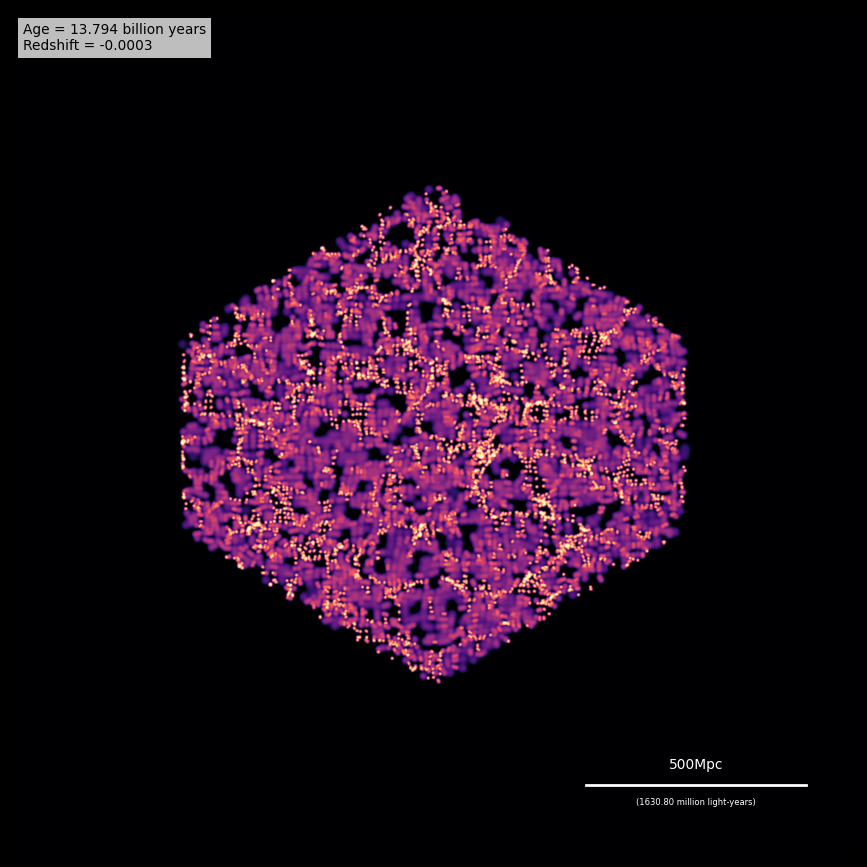

In [3]:
fig, ax = render_snapshot(snap_files[-1], plane='XY',
                          npix=NPIX, n_ngb=N_NGB, cmap=CMAP,
                          dyn_range=DYN_RANGE, figsize=11,slice_thickness=SLICE_THICKNESS)
fig.savefig(OUT_DIR / 'final_snapshot_XY.png', dpi=300,
            facecolor='black', bbox_inches='tight', pad_inches=0.02)
plt.show()

## Three projection planes

The dodecahedral fundamental domain is anisotropic, so the silhouette differs
between projection planes.

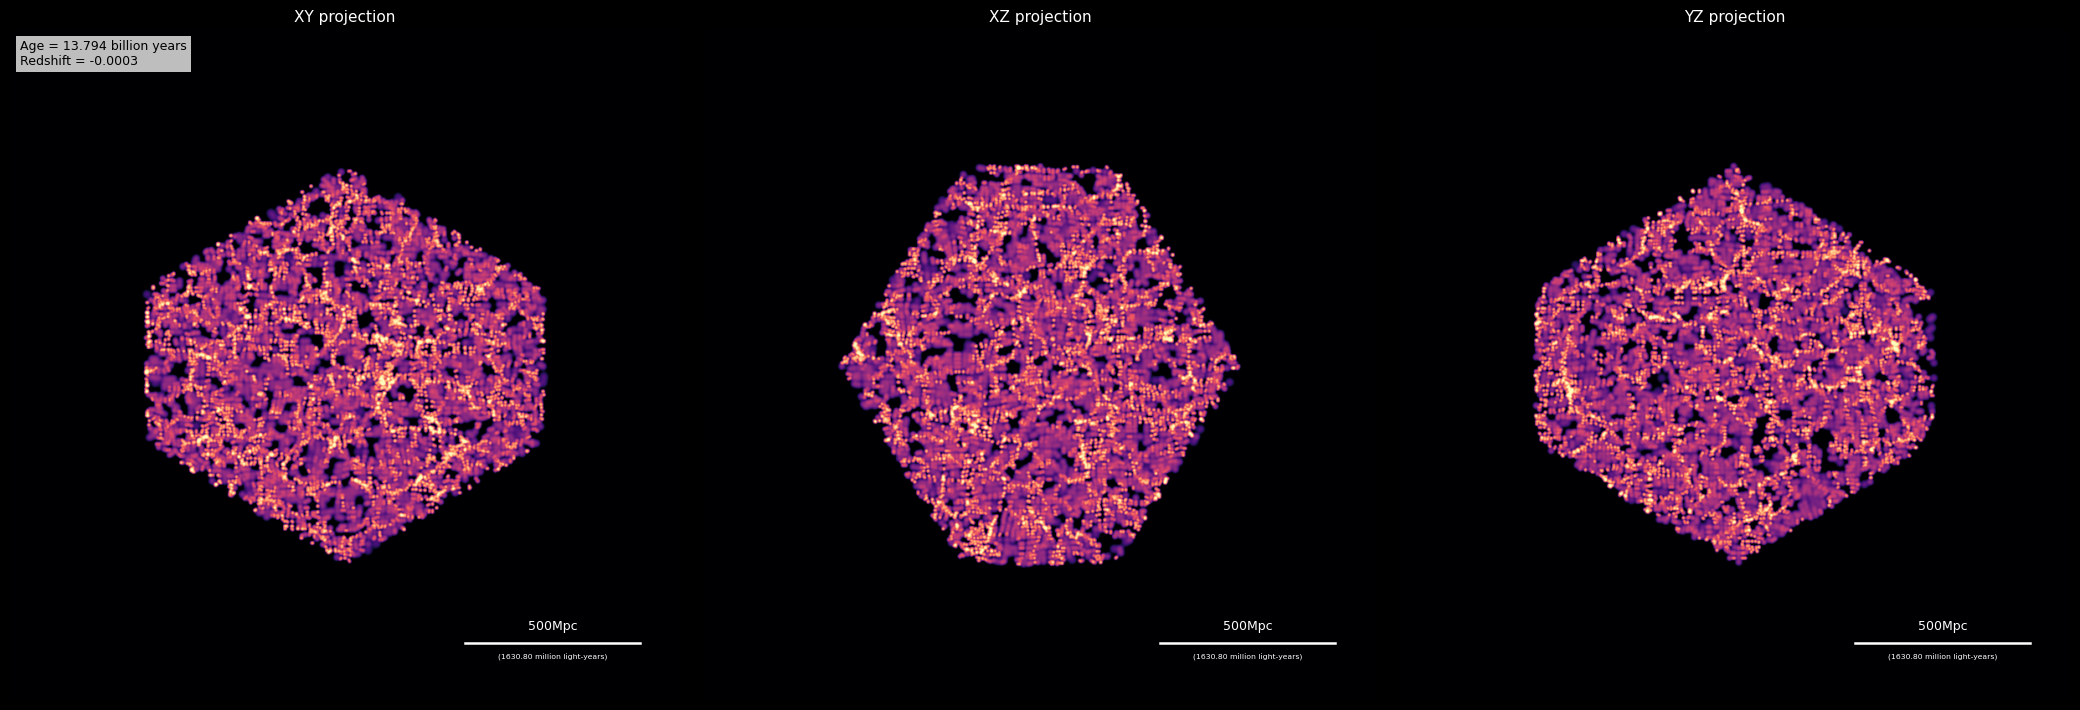

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('black')
for ax, plane in zip(axes, ['XY', 'XZ', 'YZ']):
    render_snapshot(snap_files[-1], plane=plane, npix=800, n_ngb=N_NGB, slice_thickness=SLICE_THICKNESS,
                    cmap=CMAP, dyn_range=DYN_RANGE, ax=ax,
                    info_box=(plane == 'XY'), title=f'{plane} projection')
plt.tight_layout()
plt.show()

## Evolution of the cosmic web

One panel per snapshot, from the initial grid at $z \approx 30$ to $z = 0$.
Each panel is normalized independently (the comoving density contrast grows
by orders of magnitude during the run).

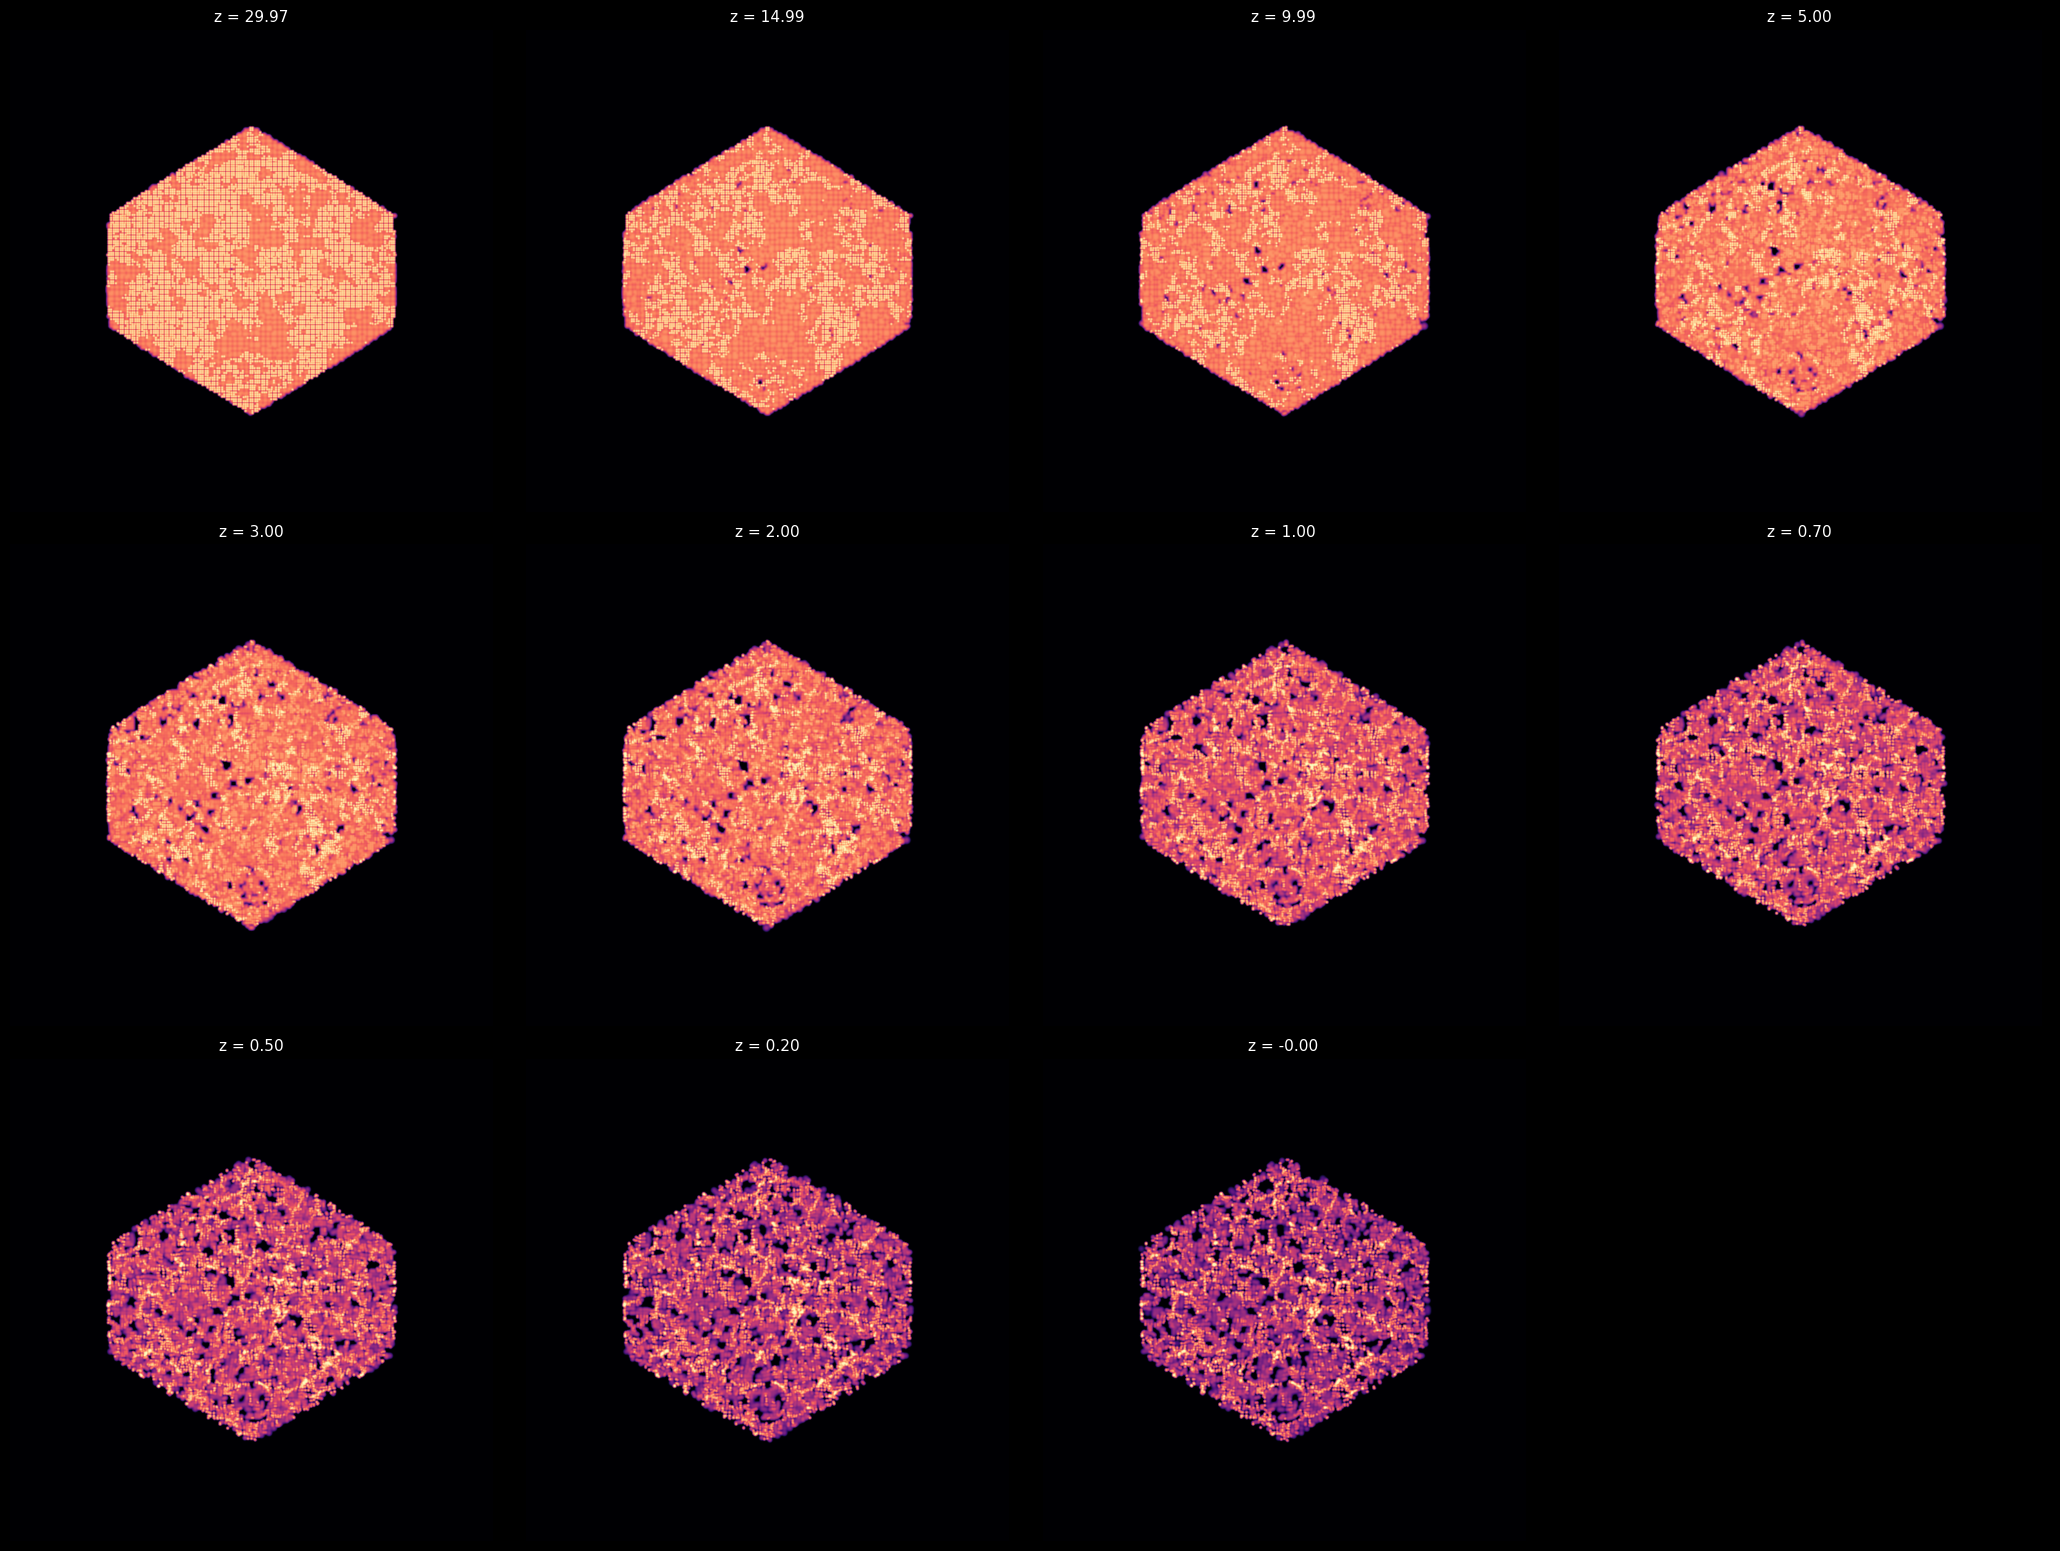

In [5]:
ncol = 4
nrow = int(np.ceil(len(snap_files) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.2*ncol, 5.2*nrow))
fig.patch.set_facecolor('black')
for ax in axes.flat:
    ax.set_axis_off()
    ax.set_facecolor('black')
for ax, s in zip(axes.flat, snap_files):
    hdr = load_snapshot(s)['hdr']
    ax.set_axis_on()
    render_snapshot(s, plane='XY', npix=700, n_ngb=N_NGB, cmap=CMAP, slice_thickness=SLICE_THICKNESS,
                    dyn_range=DYN_RANGE, ax=ax, info_box=False, scale_bar=False,
                    title=f"z = {float(hdr['Redshift']):.2f}")
plt.tight_layout()
fig.savefig(OUT_DIR / 'evolution_mosaic.png', dpi=110,
            facecolor='black', bbox_inches='tight', pad_inches=0.05)
plt.show()

## Animated GIF

Renders every snapshot to a frame and assembles `renders/evolution.gif`
(also writes the individual frames as PNGs).

In [6]:
for s in snap_files:
    hdr = load_snapshot(s)['hdr']
    fig, _ = render_snapshot(s, plane='XY', npix=NPIX, n_ngb=N_NGB,slice_thickness=SLICE_THICKNESS,
                             cmap=CMAP, dyn_range=DYN_RANGE, figsize=9)
    fig.savefig(OUT_DIR / (s.stem + '.png'), dpi=120,
                facecolor='black', bbox_inches='tight', pad_inches=0.02)
    plt.close(fig)
    print(f"rendered {s.name}  (z = {float(hdr['Redshift']):6.2f})")

make_evolution_gif(snap_files, OUT_DIR / 'evolution.gif', fps=2,
                   plane='XY', npix=NPIX, n_ngb=N_NGB,
                   cmap=CMAP, dyn_range=DYN_RANGE, figsize=9)

rendered snapshot_0000.hdf5  (z =  29.97)
rendered snapshot_0001.hdf5  (z =  14.99)
rendered snapshot_0002.hdf5  (z =   9.99)
rendered snapshot_0003.hdf5  (z =   5.00)
rendered snapshot_0004.hdf5  (z =   3.00)
rendered snapshot_0005.hdf5  (z =   2.00)
rendered snapshot_0006.hdf5  (z =   1.00)
rendered snapshot_0007.hdf5  (z =   0.70)
rendered snapshot_0008.hdf5  (z =   0.50)
rendered snapshot_0009.hdf5  (z =   0.20)
rendered snapshot_0010.hdf5  (z =  -0.00)
Wrote /scratch/csabai/test128_fix/renders/evolution.gif (11 frames)


## Parameter guide

| Parameter | Effect |
|---|---|
| `npix` | map resolution; 1000–2000 for stills, ~700 for mosaics |
| `n_ngb` | adaptive smoothing neighbours — smaller is sharper but noisier (try 8–48) |
| `dyn_range` | decades of surface density shown; larger reveals fainter structure |
| `vmax_percentile` | clip of the bright end; lower it (e.g. 99.5) if a few knots saturate |
| `cmap` | `magma`, `inferno`, `hot`, or a custom Gadget palette |
| `slice_thickness` | thin-slice mode in Mpc (like `plot_hdf5_snapshot_slice.py`); `None` = full projection |
| `r_plot` | half-size of the rendered region in Mpc (zoom with smaller values) |

`render_snapshot` accepts any StePS HDF5 snapshot — the renderer only uses
`PartType1/Coordinates`, `Masses`, and the header, so it works for spherical
and cylindrical StePS runs as well as the PDS (S³/I\*) topology.